In [1]:
import numpy as np
import pandas as pd
import os
import random
import json
from collections import defaultdict
from itertools import chain

# scikit-learn 相关
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                            accuracy_score, roc_curve, auc, roc_auc_score)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.model_selection import learning_curve

from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.base import clone
# 可视化相关
import matplotlib.pyplot as plt
import seaborn as sns

# 设置全局随机种子
np.random.seed(11)
random.seed(11)
os.environ['PYTHONHASHSEED'] = str(11)

# 其他库（如果适用，请取消注释）
# import tensorflow as tf
# tf.random.set_seed(11)
# import torch
# torch.manual_seed(11)

# 加载与保存模型等操作
import pickle
#import torch

import xgboost as xgb
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import math

In [2]:

input_dir = "/mnt/f/精浆文章/20250310/"
output_dir = "/mnt/f/精浆文章/20250310/ART_article/"
#if not exists  create output_dir
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
#set working directory
os.chdir(output_dir)

In [3]:
clin=pd.read_csv(input_dir+"ART_clin_group.txt",index_col=0,sep="\t")
print(clin)
mlnc_expression=pd.read_csv(input_dir+"Genes_TPM.txt",index_col=0,sep="\t")
print(mlnc_expression)

           group  OLI  AST   SV   PH    SC    TSC  VR   PR  PR_NP  ART
samplename                                                            
CF-R004      OLI    1    0  3.1  7.5  50.2  155.7  75  8.2    8.5    0
CF-R005      OLI    1    0  4.7  7.5  19.4   91.0  68  9.2   10.0    1
CF-R008      OLI    1    0  3.7  7.5  19.8   73.3  75  3.0    3.0    0
CF-R010      OLI    1    0  2.6  7.5  58.8  152.9  75  8.3    9.3    1
CF-R016      OLI    1    0  4.5  7.5  31.0  139.6  72  0.5    1.0    1
...          ...  ...  ...  ...  ...   ...    ...  ..  ...    ...  ...
CF-W112      AZO    0    0  7.4  7.5   0.0    0.0   0  0.0    0.0    0
CF-W116      AZO    0    0  1.8  7.5   0.0    0.0   0  0.0    0.0    0
CF-W119      AZO    0    0  2.8  7.5   0.0    0.0   0  0.0    0.0    0
CF-W122      AZO    0    0  3.7  7.5   0.0    0.0   0  0.0    0.0    0
CF-W128      AZO    0    0  3.0  7.5   0.0    0.0   0  0.0    0.0    0

[114 rows x 11 columns]
              CF-N007  CF-N012  CF-N018  CF-N027  CF

In [5]:
feature_selection=pd.read_csv(input_dir+"ART_select_feature.txt",sep="\t",header=None)
feature_selection = feature_selection[0].tolist()
feature_selection[0:5]

['NECTIN2', 'ENSG00000258422', 'TUBB3', 'SAXO1', 'FBLN2']

In [6]:
usesamplename=list(mlnc_expression.columns.intersection(clin.index))
#use usesamplename to select mlnc_expression columns
mlnc_expression_use=mlnc_expression[usesamplename]
#use usesamplename to select clin rows
clin_use=clin.loc[usesamplename]

#filter rowname feature_selection
mlnc_expression_use = mlnc_expression_use.loc[feature_selection]
mlnc_expression_use

,CF-R004,CF-R005,CF-R008,CF-R010,CF-R016,CF-R029,CF-R031,CF-R036,CF-R039,CF-R052,...,CF-W097,CF-W102,CF-W104,CF-W105,CF-W109,CF-W112,CF-W116,CF-W119,CF-W122,CF-W128
Gene,,,,,,,,,,,,,,,,,,,,,
NECTIN2,1.96,1.20,1.46,1.29,1.69,2.38,3.27,2.52,4.54,1.62,...,1.52,1.72,1.85,0.62,2.72,1.66,1.76,1.82,2.53,2.07
ENSG00000258422,0.00,0.99,0.52,0.87,0.91,0.33,0.49,0.49,0.31,0.77,...,0.23,0.00,0.13,0.00,0.00,0.70,0.10,0.00,0.35,0.33
TUBB3,0.80,2.38,0.48,0.88,4.05,1.12,5.51,1.63,2.52,1.82,...,0.93,0.67,0.91,0.79,0.96,0.71,0.46,0.82,0.83,0.75
SAXO1,0.17,0.82,0.54,0.35,0.46,0.30,0.53,0.55,0.72,0.28,...,0.11,0.09,0.07,0.05,0.29,0.23,0.17,0.12,0.26,0.27
FBLN2,0.06,0.59,0.09,0.76,0.02,0.49,0.56,0.00,0.15,0.90,...,0.78,0.14,0.68,0.12,0.40,0.10,0.59,0.02,0.50,0.32
LURAP1L-AS1,0.19,0.00,0.00,0.24,0.01,0.00,0.03,0.07,0.03,0.00,...,0.00,1.01,0.15,0.19,0.00,0.46,0.00,0.35,0.26,0.00
CLIP2,0.51,0.19,0.36,0.39,0.36,0.00,0.63,0.23,0.57,0.31,...,0.36,0.19,0.16,0.05,0.49,0.17,0.41,0.20,0.04,0.21
ENSG00000233633,0.06,0.19,0.41,0.00,0.04,0.32,0.09,0.09,0.86,0.08,...,0.00,0.50,0.04,0.02,0.21,0.04,0.12,0.17,0.16,0.36
BCL2L15,0.11,0.11,0.07,0.43,0.11,0.18,0.03,0.25,0.00,0.00,...,0.03,1.36,0.07,0.05,0.04,0.05,0.03,0.00,0.05,0.11


In [7]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from scipy.stats import pearsonr

#preprocessing
from sklearn import preprocessing
#LinearRegression
from sklearn.linear_model import LinearRegression
# mean_squared_error and mean_absolute_error and r2_score 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [8]:
mlnc_expression_use_filtered=mlnc_expression_use
X=mlnc_expression_use_filtered.T
y=clin_use["ART"]
name = "ART"
Y = y
X = np.asarray(X)
X = np.nan_to_num(X)
y = np.asarray(Y)
min_max_scaler = preprocessing.MinMaxScaler()
X = min_max_scaler.fit_transform(X)
X = np.asarray(X,dtype=np.float32)

In [9]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
results = {
    'Fold': [],
    'train auc': [],
    'test auc': []
}

# 用于存储所有折的真实值、预测概率和折号
true_values = []
predicted_probabilities = []
fold_indices = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f'Fold {fold}')
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = LogisticRegression(random_state=42)
    sc = StandardScaler() 
    sc.fit(X_train) 
    X_train = sc.transform(X_train) 
    X_test = sc.transform(X_test) 
    model.fit(X_train, y_train)
    
    y_test_pred_prob = model.predict_proba(X_test)
    y_train_pred_prob = model.predict_proba(X_train)
    train_auc = roc_auc_score(y_train, y_train_pred_prob[:, 1])
    test_auc = roc_auc_score(y_test, y_test_pred_prob[:, 1])
    
    results['Fold'].append(fold)
    results['train auc'].append(train_auc)
    results['test auc'].append(test_auc)


    #######shape##########
    #X_train dim 
    X_train.shape
    #set X colname as feature_selection
    X_train_tmp=pd.DataFrame(X_train,columns=feature_selection)
    X_test_tmp= pd.DataFrame(X_test,columns=feature_selection) 
    import shap
    # 初始化解释器
    explainer = shap.LinearExplainer(model, X_train_tmp)

    # 计算SHAP值
    shap_values = explainer.shap_values(X_train_tmp)

    # 可视化第一个预测的SHAP值
    #shap.initjs()  # 用于在Jupyter笔记本中的可视化

    # 对于二分类问题，shap_values将是一个数组
    shap.summary_plot(shap_values, X_train_tmp, plot_type="violin", show=False)

    # 将图保存为PDF文件
    plt.savefig(output_dir+name+"_fold"+str(fold)+"_shap_summary_plot.pdf")
    plt.close()

    true_values.extend(y_test)
    predicted_probabilities.extend(y_test_pred_prob[:, 1])
    fold_indices.extend([fold] * len(test_index))
    
    fold += 1

results_df = pd.DataFrame(results)
results_df.to_csv(output_dir+name + '_cross_validation_results.csv', index=False)

# 将所有真实值、预测概率和折号转换为数组
true_values = np.array(true_values)
predicted_probabilities = np.array(predicted_probabilities)
fold_indices = np.array(fold_indices)

# 计算整体样本的auc
overall_auc = roc_auc_score(true_values, predicted_probabilities)

overall_results = {
    'Overall auc': [overall_auc]
}

overall_results_df = pd.DataFrame(overall_results)
overall_results_df.to_csv(output_dir+name + '_overall_results.csv', index=False)

print('Cross-validation results:')
print(results_df)
print('Overall results:')
print(overall_results_df)

print('mean test auc:', results_df['test auc'].mean())

# 合并 y、overall_predictions 和 fold_indices 并保存
y_df = pd.DataFrame(true_values, columns=['true'])
overall_predictions_df = pd.DataFrame(predicted_probabilities, columns=['predicted'])
fold_indices_df = pd.DataFrame(fold_indices, columns=['fold'])
pred_and_true = pd.concat([y_df, overall_predictions_df, fold_indices_df], axis=1)
pred_and_true.index = usesamplename
pred_and_true.to_csv(output_dir+name + '_predicted_and_true.csv')

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
Cross-validation results:
   Fold  train auc  test auc
0     1   0.982759  1.000000
1     2   0.983099  0.875000
2     3   0.988678  1.000000
3     4   0.993859  0.933333
4     5   0.985007  0.875000
5     6   0.987963  1.000000
6     7   0.987279  1.000000
7     8   0.985068  1.000000
8     9   0.986370  1.000000
9    10   0.987963  1.000000
Overall results:
   Overall auc
0     0.946389
mean test auc: 0.9683333333333334


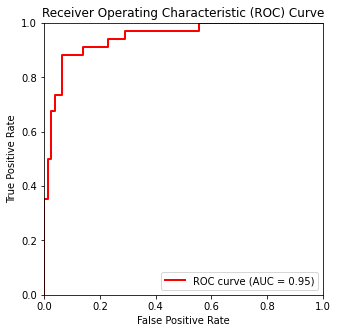

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 从 pred_and_true DataFrame 中提取真实值和预测概率
true_values = pred_and_true['true'].values
predicted_probabilities = pred_and_true['predicted'].values

# 计算 ROC 曲线
fpr, tpr, thresholds = roc_curve(true_values, predicted_probabilities)
roc_auc = auc(fpr, tpr)

# 创建图形
plt.figure(figsize=(5, 5))

# 绘制 ROC 曲线
plt.plot(fpr, tpr, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 添加标题和标签
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')


# 添加图例
plt.legend(loc='lower right')
# 设置坐标范围
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
#save as pdf
plt.savefig(output_dir+name+'_all_roc_plot.pdf')
# 显示图形
plt.show()

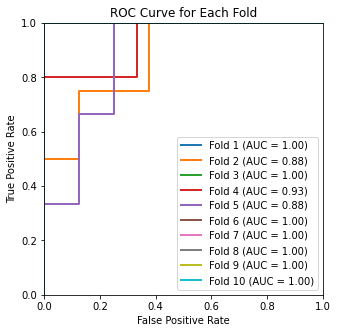

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 读取 pred_and_true DataFrame
pred_and_true = pd.read_csv(output_dir+name + '_predicted_and_true.csv')

# 获取所有折号
folds = pred_and_true['fold'].unique()

# 创建图形
plt.figure(figsize=(5, 5))

# 遍历每个折号，绘制每个折的ROC曲线
for fold in folds:
    fold_data = pred_and_true[pred_and_true['fold'] == fold]
    true_values = fold_data['true'].values
    predicted_probabilities = fold_data['predicted'].values

    # 计算 ROC 曲线
    fpr, tpr, thresholds = roc_curve(true_values, predicted_probabilities)
    roc_auc = auc(fpr, tpr)

    # 绘制 ROC 曲线
    plt.plot(fpr, tpr, lw=2, label=f'Fold {fold} (AUC = {roc_auc:.2f})')


# 添加标题和标签
plt.title('ROC Curve for Each Fold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

# 添加图例
plt.legend(loc='lower right')

# 设置坐标范围
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
#save as pdf
plt.savefig(output_dir+name+'_10fold_roc_plot.pdf')
# 显示图形
plt.show()

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score


# 提取真实值和预测概率
true_values = pred_and_true['true'].values
predicted_probabilities = pred_and_true['predicted'].values

# 定义不同的阈值
thresholds = predicted_probabilities

# 初始化用于存储结果的变量
f1_scores = []
sensitivities = []
specificities = []
accuracies = []
tps = []
fps = []
tns = []
fns = []

# 计算每个阈值下的F1值、敏感性、特异性、准确率
for threshold in thresholds:
    # 将预测概率转化为预测标签
    predicted_labels = (predicted_probabilities >= threshold).astype(int)
    
    # 计算混淆矩阵
    cm = confusion_matrix(true_values, predicted_labels)
    
    # 从混淆矩阵中提取TP、FP、TN、FN
    tn, fp, fn, tp = cm.ravel()
    
    # 计算各项指标
    accuracy = accuracy_score(true_values, predicted_labels)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(true_values, predicted_labels)
    
    # 存储结果
    f1_scores.append(f1)
    sensitivities.append(sensitivity)
    specificities.append(specificity)
    accuracies.append(accuracy)
    tps.append(tp)
    fps.append(fp)
    tns.append(tn)
    fns.append(fn)

# 转换为DataFrame
results_df = pd.DataFrame({
    'Threshold': thresholds,
    'F1 Score': f1_scores,
    'Sensitivity': sensitivities,
    'Specificity': specificities,
    'Accuracy': accuracies,
    'TP': tps,
    'FP': fps,
    'TN': tns,
    'FN': fns
})

# 找到F1值最大的阈值
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
best_f1 = f1_scores[best_threshold_idx]
best_sensitivity = sensitivities[best_threshold_idx]
best_specificity = specificities[best_threshold_idx]
best_accuracy = accuracies[best_threshold_idx]
best_tp = tps[best_threshold_idx]
best_fp = fps[best_threshold_idx]
best_tn = tns[best_threshold_idx]
best_fn = fns[best_threshold_idx]

best_results_df = pd.DataFrame({
    'Best Threshold': [best_threshold],
    'Best F1 Score': [best_f1],
    'Best Sensitivity': [best_sensitivity],
    'Best Specificity': [best_specificity],
    'Best Accuracy': [best_accuracy],
    'Best TP': [best_tp],
    'Best FP': [best_fp],
    'Best TN': [best_tn],
    'Best FN': [best_fn]
})


# 打印结果
print(f'Best Threshold: {best_threshold:.2f}')
print(f'Best F1 Score: {best_f1:.2f}')
print(f'Sensitivity: {best_sensitivity:.2f}')
print(f'Specificity: {best_specificity:.2f}')
print(f'Accuracy: {best_accuracy:.2f}')
print(f'TP: {best_tp}')
print(f'FP: {best_fp}')
print(f'TN: {best_tn}')
print(f'FN: {best_fn}')

# 将结果保存为CSV文件
results_df.to_csv(output_dir+name + '_threshold_analysis.csv', index=False)

best_results_df.to_csv(output_dir+name + '_best_threshold_analysis.csv', index=False)


Best Threshold: 0.36
Best F1 Score: 0.87
Sensitivity: 0.88
Specificity: 0.94
Accuracy: 0.92
TP: 30
FP: 5
TN: 74
FN: 4
